In [ ]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from matplotlib import offsetbox
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions
from nflows.transforms.normalization import ActNorm
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

from src.diffeomorphisms.image.nflow import NFlowImageDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.image.l2_tangent_space_pca import l2TangentSpacePCAImageSolver
from src.inverse_problems.ambient_flow import AmbientFlowProblem
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.manifolds.euclidean.image.standard import StandardImageEuclidean
from src.transforms.multi_layer_parity_conv2d.tanh import MultiLayerTanhParityConv2DTransform
from src.transforms.parity_conv import ParityConv2DTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

# Experiment settings
results_folder = os.path.join("results","mnist","tanh")
train_model = True

### Generate data ###

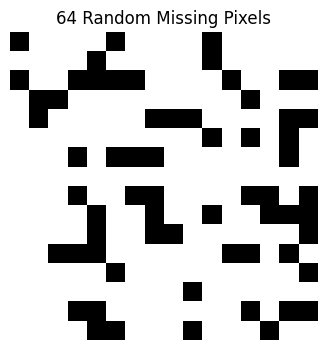

In [10]:
def create_exact_missing_mask(H, W, M):
    # Initialize all present (0s)
    mask = torch.ones(H * W, dtype=torch.bool)
    
    # Generate unique random indices
    indices = torch.randperm(H * W, device=device)[:M]
    
    # Set missing pixels
    mask[indices] = False
    
    return mask.view(H, W)

# Create mask
H, W = 16, 16
M = int(0.25 * H * W)

mask = create_exact_missing_mask(H, W, M)

plt.figure(figsize=(4,4))
plt.imshow(mask.cpu(), cmap='gray', interpolation='nearest')
plt.title(f'{M} Random Missing Pixels')
plt.axis('off')
plt.show()

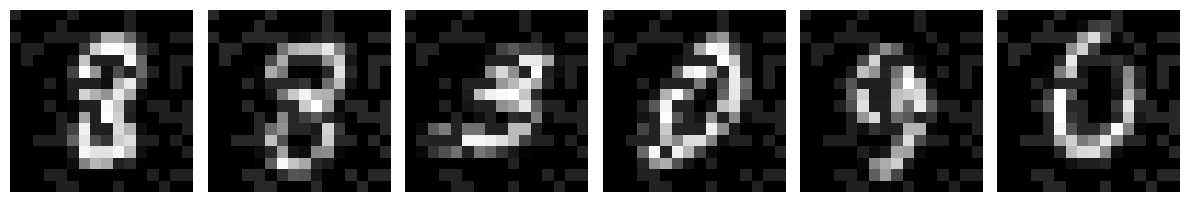

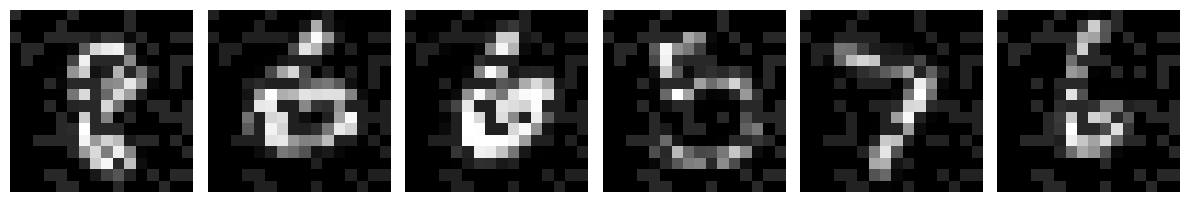

In [ ]:
# Construct dataset
mnist_mean = 0.1307
mnist_var = 0.3081

# Define the transform
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

# Load the full MNIST dataset
full_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Calculate the split point (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Create train and validation subsets
data_train_clean, data_val_clean = random_split(full_dataset, [train_size, val_size])

# add noise
noise_level = 0.1
data_train = [] # noise + mask
data_val = []

# Create the DataLoaders
batch_size = 128
train_loader = DataLoader(data_train, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(data_val, batch_size=batch_size, shuffle=False)

# Get a batch of examples from the training set
train_examples = next(iter(train_loader))
train_images, _ = train_examples
val_examples = next(iter(val_loader))
val_images, val_labels = val_examples

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(train_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(val_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Learning Geometry ###

In [ ]:
class MaskedForward(nn.Module):
    def __init__(self, mask):
        super().__init__()
        self.mask = mask
    
    def forward(self, x):
        return self.mask * x

In [ ]:
# Define the normalizing flow model
def create_flow_model(in_channels, height, width, kernel_size, latent_channels, order, n_flows, unit_det=False, parity_equivariance=False):
    base_dist = distributions.StandardNormal(shape=[in_channels, height, width])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(MultiLayerTanhParityConv2DTransform(in_channels, height, width, kernel_size, latent_channels, order=order, parity=i))
    transforms_list.append(ActNorm(features=in_channels))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows, unit_det=unit_det, parity_equivariance=parity_equivariance))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)

In [ ]:
# Define the conditional normalizing flow model
def create_conditional_flow_model(in_channels, height, width, kernel_size, latent_channels, order, n_flows, unit_det=False, parity_equivariance=False):
    context_encoder = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 2*in_channels, 3, padding=1)
        )
    base_dist = distributions.ConditionalDiagonalNormal(shape=[in_channels, height, width], context_encoder=context_encoder)
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(MultiLayerTanhParityConv2DTransform(in_channels, height, width, kernel_size, latent_channels, order=order, parity=i))
    transforms_list.append(ActNorm(features=in_channels))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows, unit_det=unit_det, parity_equivariance=parity_equivariance))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)


In [ ]:
# Initialize the model
forward = MaskedForward(mask)

L = 128
K = 5
order = 6
n_flows = 6
prior_flow = create_flow_model(1, H, W, K, L, order, n_flows).to(device)
prior_diffeo = NFlowImageDiffeomorphism(1, H, W, prior_flow)

posterior_flow = create_conditional_flow_model(1, H, W, K, L, order, n_flows).to(device)
posterior_diffeo = NFlowImageDiffeomorphism(1, H, W, prior_flow)

model = AmbientFlowProblem(forward, prior_diffeo, posterior_diffeo, noise_level, reg_param=0.1).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# Training loop
def train(model, train_loader, optimizer, n_epochs, save_dir='results', start_epoch=0, real_data_reg=None):
    best_loss = float('inf')
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0
        for y, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}"):
            optimizer.zero_grad()
            
            # Compute loss
            loss = model.reconstruction_loss(y)

            if real_data_reg is not None:
                log_p_theta_gt = model.phi.nflow.log_prob(data_train_clean[0:batch_size].to(device))
                loss -= real_data_reg * log_p_theta_gt.mean()

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        
        # Calculate average loss for the epoch
        avg_epoch_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{n_epochs}, Average Loss: {avg_epoch_loss:.4f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
            'best_loss': best_loss,
        }
        
        if (epoch + 1) % 25 == 0:
            torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [ ]:
# Train the model
n_epochs = 100
checkpoint_dir = os.path.join(results_folder, f"checkpoints_latent_dim={L}_kernel_size={K}_order={order}_n_flows={n_flows}")

# Train or load model
if train_model:
    start_epoch = 0
    best_loss = float('inf')

    # Check if there's a checkpoint to resume from
    latest_checkpoint = max(glob.glob(os.path.join(checkpoint_dir, 'epoch_*_model.pth')), default=None, key=os.path.getctime)
    
    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_loss = checkpoint['best_loss']

    train(model, train_loader, optimizer, n_epochs, save_dir=checkpoint_dir, start_epoch=start_epoch)
else:
    # best_model_path = os.path.join(checkpoint_dir, 'epoch_200_model.pth')
    best_model_path = os.path.join(checkpoint_dir, 'best_model.pth')
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])

# Set the model to evaluation mode
model.eval()

Epoch 1/100: 100%|██████████| 375/375 [01:02<00:00,  6.01it/s]


Epoch 1/100, Average Loss: 907.8959


Epoch 2/100: 100%|██████████| 375/375 [01:00<00:00,  6.20it/s]


Epoch 2/100, Average Loss: 446.1028


Epoch 3/100: 100%|██████████| 375/375 [00:59<00:00,  6.30it/s]


...

Epoch 99/100: 100%|██████████| 375/375 [01:00<00:00,  6.20it/s]


Epoch 99/100, Average Loss: -15489.0912


Epoch 100/100: 100%|██████████| 375/375 [00:59<00:00,  6.29it/s]


Epoch 100/100, Average Loss: -15656.3503
Training completed. Best model saved with loss: -15656.350294270833


NFlowImageDiffeomorphism(
  (nflow): Flow(
    (_transform): CompositeTransform(
      (_transforms): ModuleList(
        (0): ActNorm()
        (1-2): 2 x ParityConv2DTransform(
          (conv2d): Conv2d(1, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
        )
        (3): MultiLayerTanhParityConv2DTransform(
          (cnn): Sequential(
            (0): MaskedConv2d(1, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): TanhActivation()
            (2): MaskedConv2d(128, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (3): TanhActivation()
            (4): MaskedConv2d(128, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
          )
        )
        (4): ActNorm()
        (5-6): 2 x ParityConv2DTransform(
          (conv2d): Conv2d(1, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
        )
        (7): MultiLayerTanhParityConv2DTransform(
          (cnn): Sequential(
            (0): MaskedConv

In [ ]:
# Generate samples
@torch.no_grad()
def generate_samples(model, n_samples):
    samples = model.sample(n_samples).cpu()
    return samples

In [ ]:
# Generate conditional samples
@torch.no_grad()
def generate_samples_with_context(model, n_samples, context):
    samples = model.sample(n_samples, context=context[None]).squeeze().cpu()
    return samples

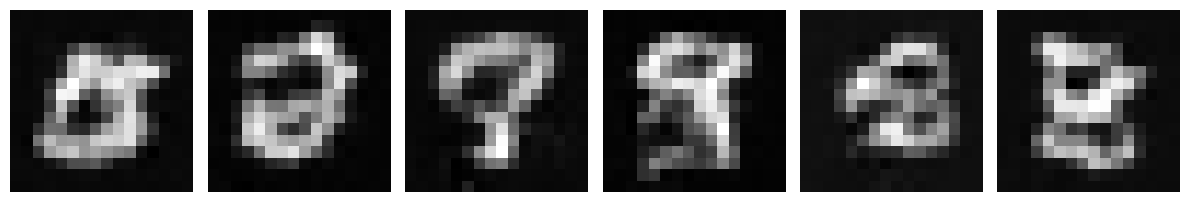

In [8]:
# Visualize generated samples
samples = generate_samples(phi.nflow, 100).reshape(-1,H,W)

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(samples[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Evaluating Geometry ###

In [9]:
# Construct reference manifold
ref_manifold = StandardImageEuclidean(1, H, W)

# Construct pullback manifold
phi_manifold = StandardPullbackImageEuclidean(phi)

# Construct isometrized pullback manifold
iso_manifold = l2IsometrizedImageEuclidean(phi_manifold)

In [10]:
# Compute geodesics
# Define the dimensions
num_points = num_geodesics = 16

ref_geodesics = torch.zeros(num_geodesics, num_points, 1, H, W)
phi_geodesics = torch.zeros(num_geodesics, num_points, 1, H, W)

# Generate random indices without repetition
indices0 = torch.randperm(batch_size)[:num_points]
indices1 = torch.randperm(batch_size)[:num_points]

# Create x0 and x1 tensors
x0 = val_images[0:2*num_geodesics:2].to(device)
x1 = val_images[1:2*num_geodesics+1:2].to(device)

# Create a grid of points
t = torch.linspace(0., 1., num_points).to(device)

# Generate geodesics
for i in range(num_geodesics):
    ref_geodesics[i] = ref_manifold.geodesic(x0[i], x1[i], t).detach().cpu()
    phi_geodesics[i] = phi_manifold.geodesic(x0[i], x1[i], t).detach().cpu()

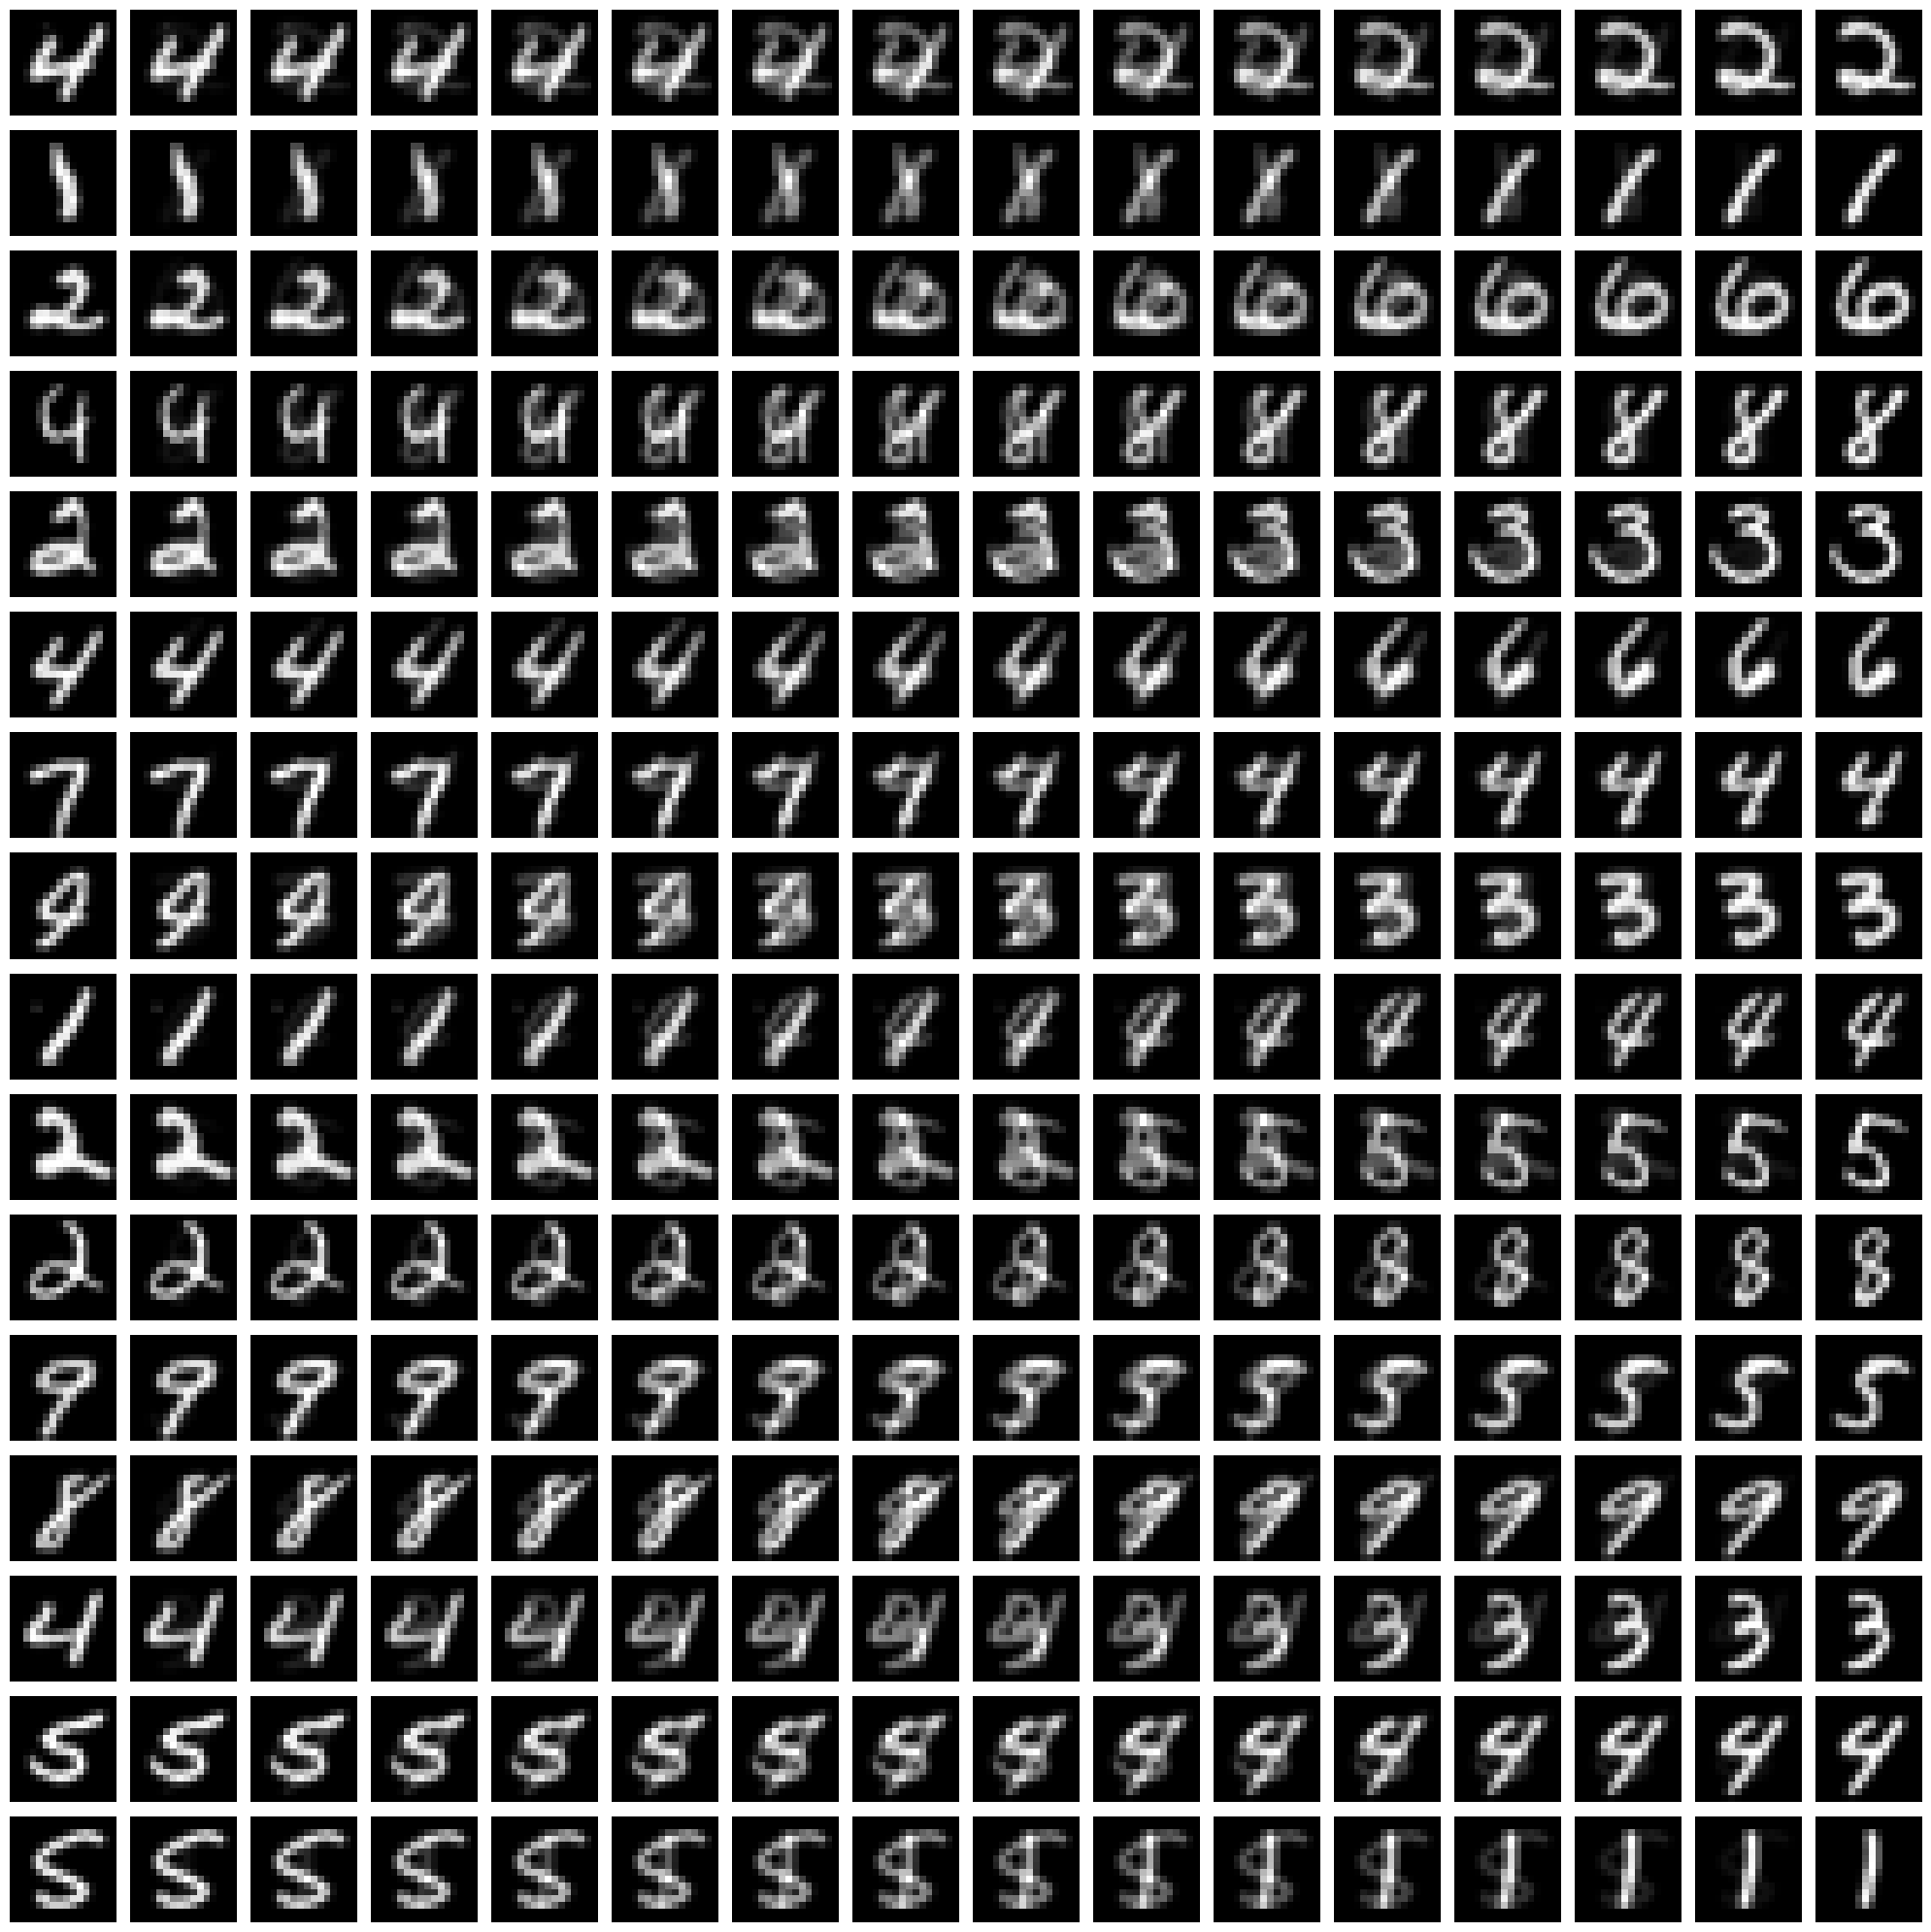

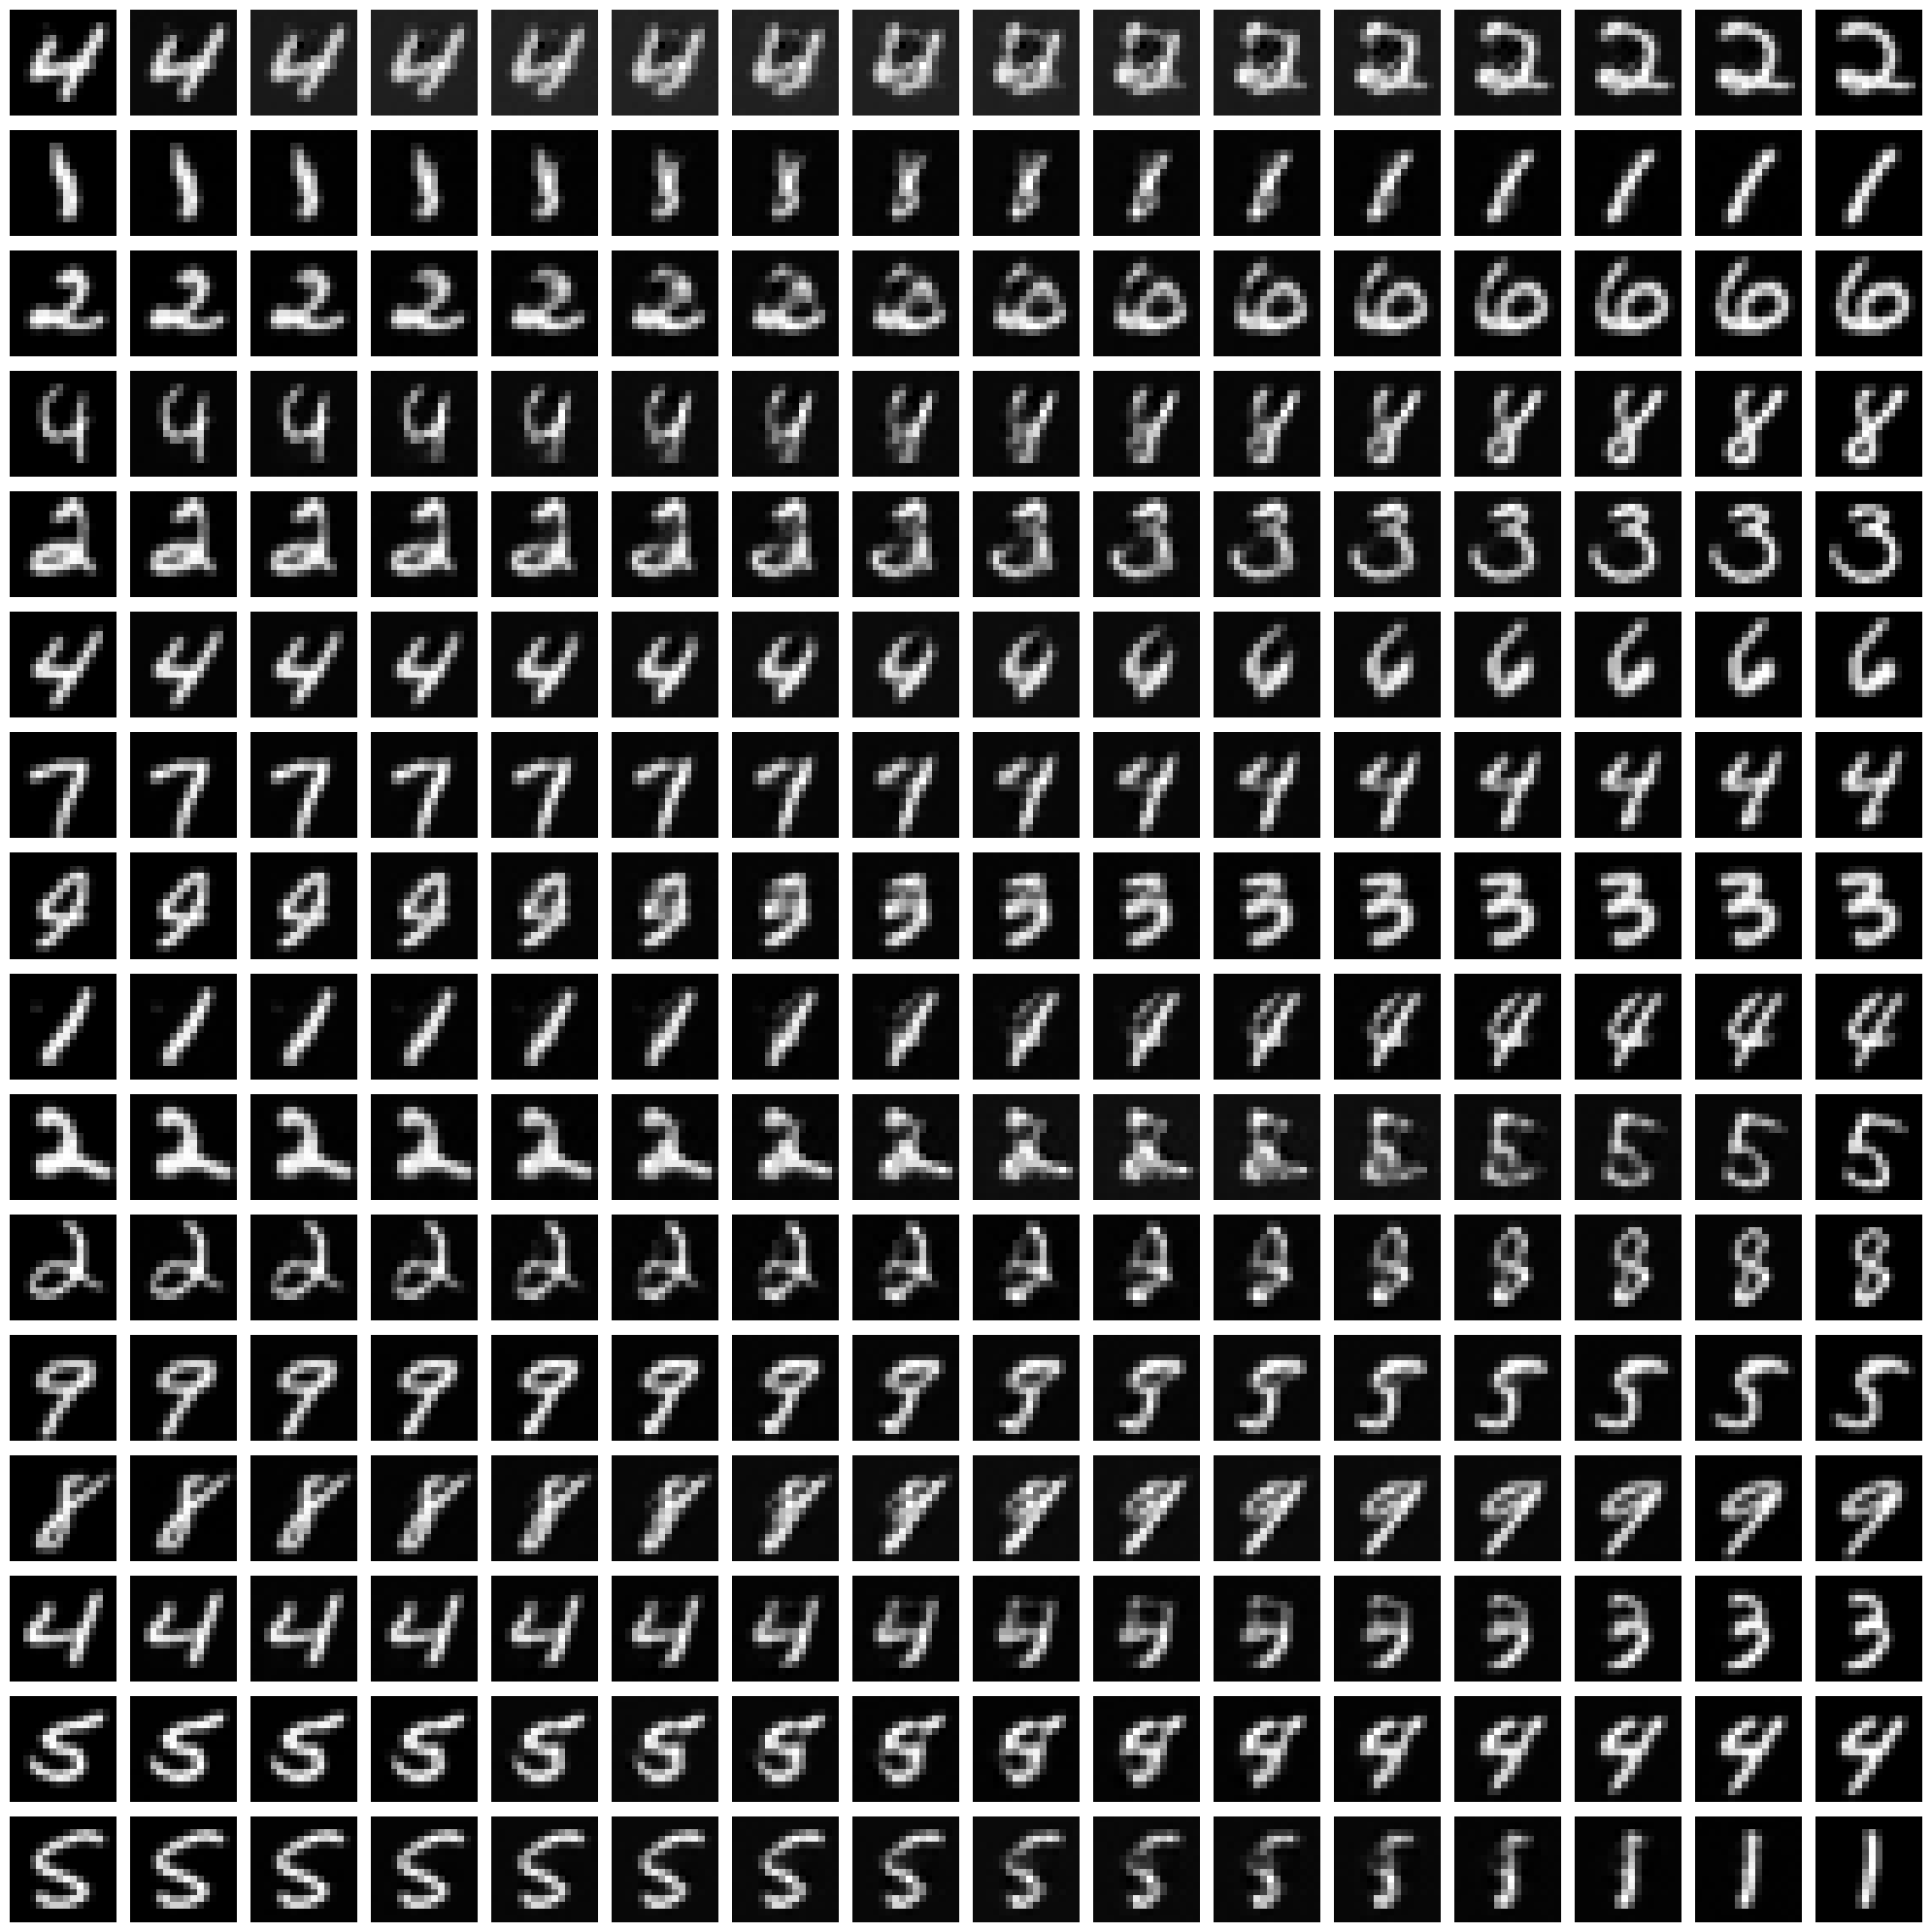

In [11]:
# Create a 16x16 grid of subplots
fig, axes = plt.subplots(num_geodesics, num_points, figsize=(20, 20))

# Plot each image in the grid
for i in range(num_geodesics):
    for j in range(num_points):
        axes[i, j].imshow(ref_geodesics[i, j].squeeze(), cmap='gray')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

# Create a 16x16 grid of subplots
fig, axes = plt.subplots(num_geodesics, num_points, figsize=(20, 20))

# Plot each image in the grid
for i in range(num_geodesics):
    for j in range(num_points):
        axes[i, j].imshow(phi_geodesics[i, j].squeeze(), cmap='gray')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Compute barycentre
ref_bary = ref_manifold.barycentre(val_images.to(device)).cpu()
phi_bary = phi_manifold.barycentre(val_images.to(device)).cpu()

# Choose bary for subsequent experiments
bary = phi_bary

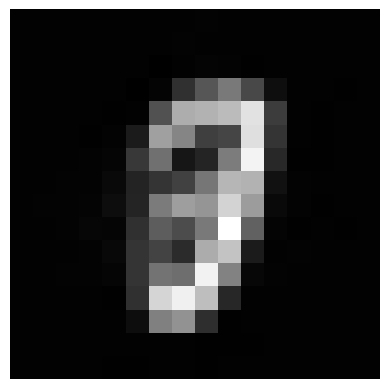

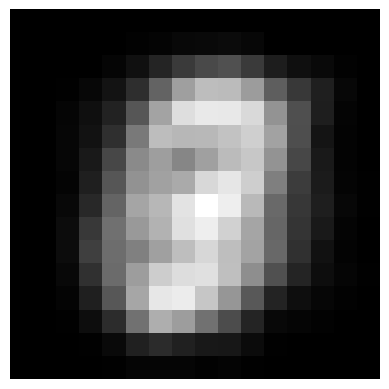

In [13]:
# Plot barycentres
plt.imshow(phi_bary.squeeze().detach().cpu().numpy(), cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(ref_bary.squeeze().detach().cpu().numpy(), cmap='gray')
plt.axis('off')
plt.show()

In [14]:
# Construct curvature corrected l2-pga solver
ref_l2_pga_solver = l2TangentSpacePCAImageSolver(val_images, ref_manifold, bary, device=device)
phi_l2_pga_solver = l2TangentSpacePCAImageSolver(val_images, phi_manifold, bary, device=device)

In [ ]:
# Compute low rank approximations
plt_rank = 20
max_rank = 50
discard_highest_error = 20

ref_rel_errors = []
ref_restricted_rel_errors = []
phi_rel_errors = []
phi_restricted_rel_errors = []

for i in range(max_rank):
    _, _, ref_error_dict_ = ref_l2_pga_solver.solve(i+1, discard_highest_error=discard_highest_error)
    ref_rel_errors.append(ref_error_dict_['rel_error'])
    ref_restricted_rel_errors.append(ref_error_dict_['restricted_rel_error'])
    _, _, phi_error_dict_ = phi_l2_pga_solver.solve(i+1, discard_highest_error=discard_highest_error) 
    phi_rel_errors.append(phi_error_dict_['rel_error'])
    phi_restricted_rel_errors.append(phi_error_dict_['restricted_rel_error'])

ref_Xi, ref_exp_x_Xi, ref_error_dict = ref_l2_pga_solver.solve(plt_rank, discard_highest_error=discard_highest_error)
ref_discarded_data = ref_error_dict['discarded_data']
ref_errors = ref_error_dict['errors']
phi_Xi, phi_exp_x_Xi, phi_error_dict = phi_l2_pga_solver.solve(plt_rank, discard_highest_error=discard_highest_error)
phi_discarded_data = phi_error_dict['discarded_data']
phi_errors = phi_error_dict['errors']

Computing rank 1 approximation on tangent space
Computing rank 1 approximation on euclidean space
Computing rank 1 errors
Computing rank 1 approximation on tangent space
Computing rank 1 approximation on euclidean space
Computing rank 1 errors
Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors
Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors
Computing rank 3 approximation on tangent space
Computing rank 3 approximation on euclidean space
Computing rank 3 errors
Computing rank 3 approximation on tangent space
Computing rank 3 approximation on euclidean space
Computing rank 3 errors
Computing rank 4 approximation on tangent space
Computing rank 4 approximation on euclidean space
Computing rank 4 errors
Computing rank 4 approximation on tangent space
Computing rank 4 approximation on euclidean space
Computing rank 4 errors
Computing rank 5 approxi

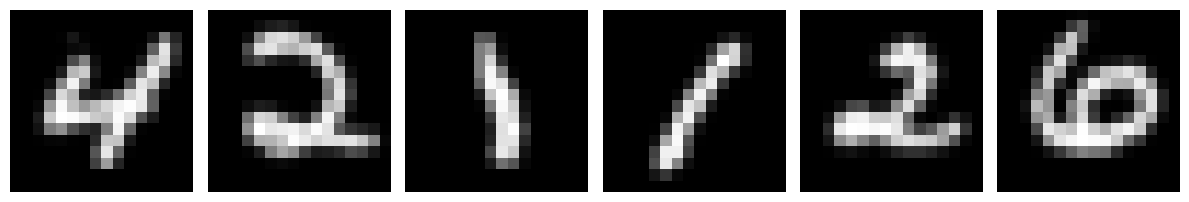

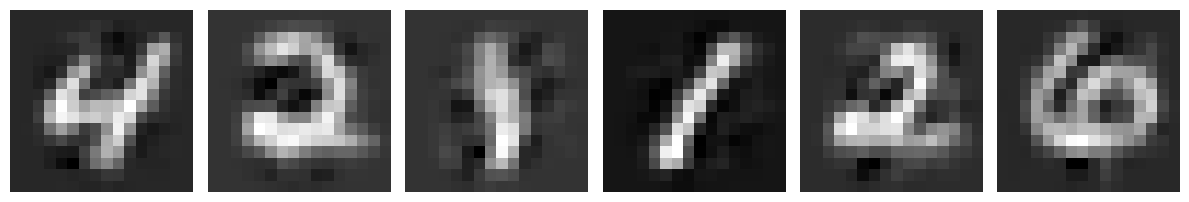

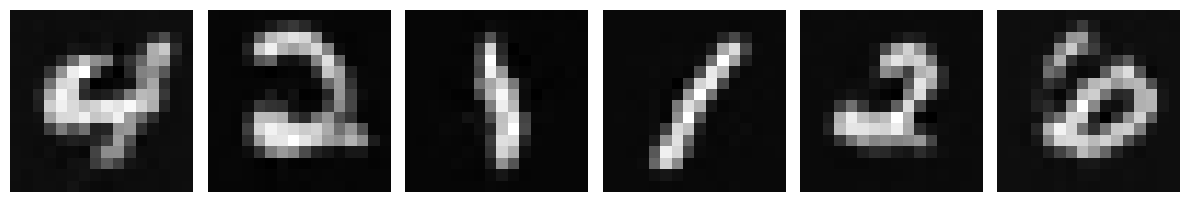

In [32]:
# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()
for i in range(6):
    axes[i].imshow(val_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()
for i in range(6):
    axes[i].imshow(ref_exp_x_Xi.squeeze().detach().cpu().numpy()[i], cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()
for i in range(6):
    axes[i].imshow(phi_exp_x_Xi.squeeze().detach().cpu().numpy()[i], cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

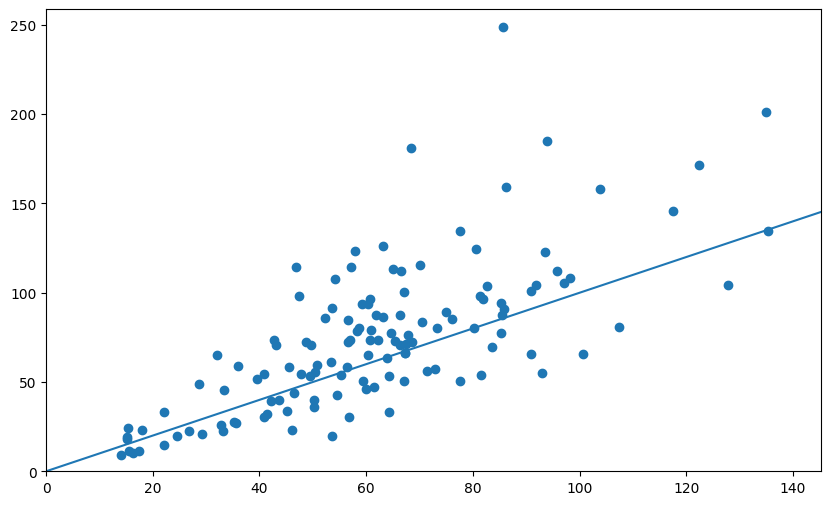

In [17]:
# Plot error histograms
plt.figure(figsize=(10, 6))
plt.scatter(ref_errors, phi_errors)
plt.plot(torch.linspace(0., ref_errors.max()+10, 100), torch.linspace(0., ref_errors.max()+10, 100))
plt.xlim([0., ref_errors.max()+10])
plt.ylim([0., phi_errors.max()+10])
plt.show()

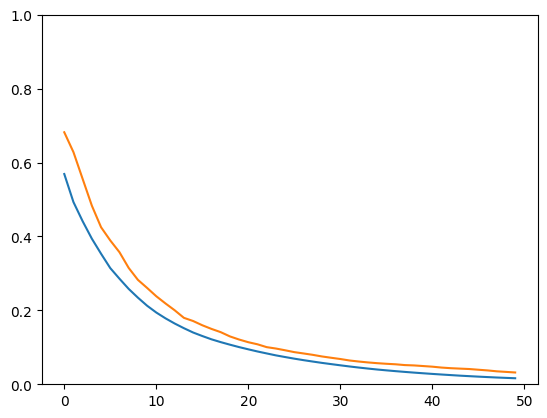

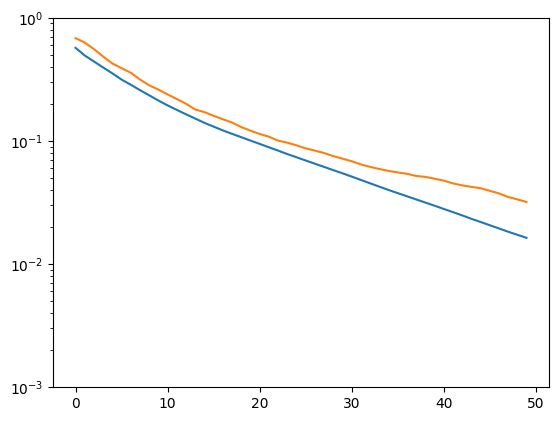

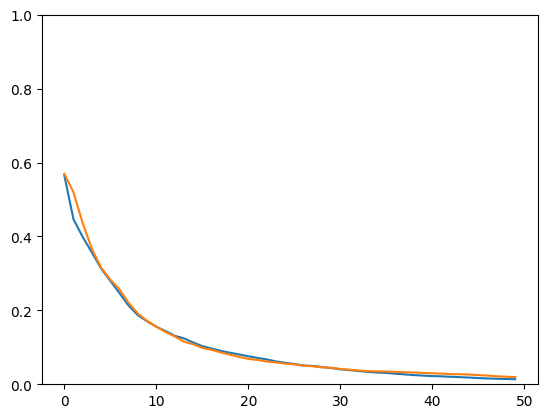

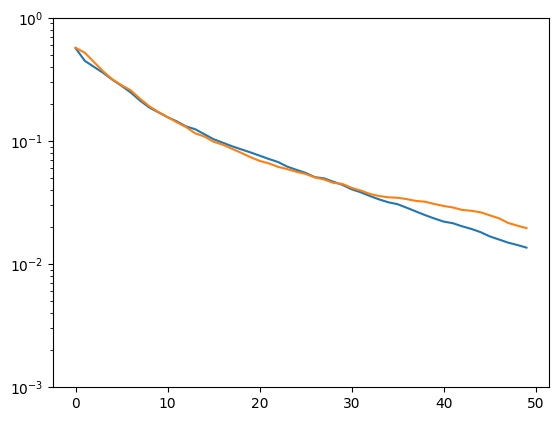

In [34]:
# Plot relative errors
plt.plot(range(max_rank), ref_rel_errors)
plt.plot(range(max_rank), phi_rel_errors)
plt.ylim([0,1])
plt.show()

plt.plot(range(max_rank), ref_rel_errors)
plt.plot(range(max_rank), phi_rel_errors)
plt.ylim([1e-3,1])
plt.yscale('log')
plt.show()

plt.plot(range(max_rank), ref_restricted_rel_errors)
plt.plot(range(max_rank), phi_restricted_rel_errors)
plt.ylim([0,1])
plt.show()

plt.plot(range(max_rank), ref_restricted_rel_errors)
plt.plot(range(max_rank), phi_restricted_rel_errors)
plt.ylim([1e-3,1])
plt.yscale('log')
plt.show()

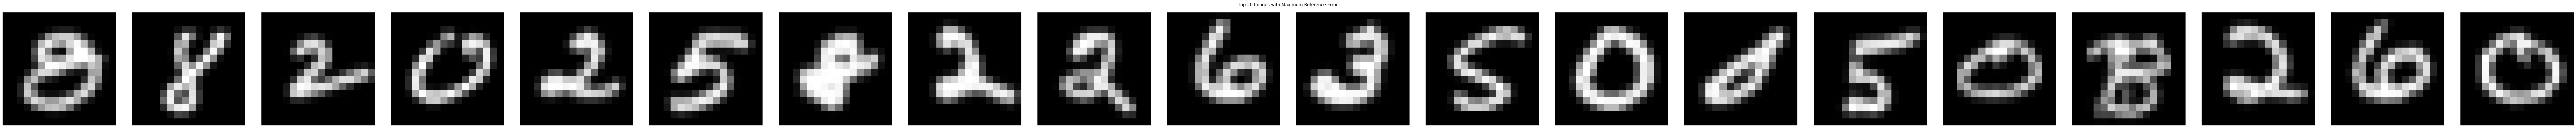

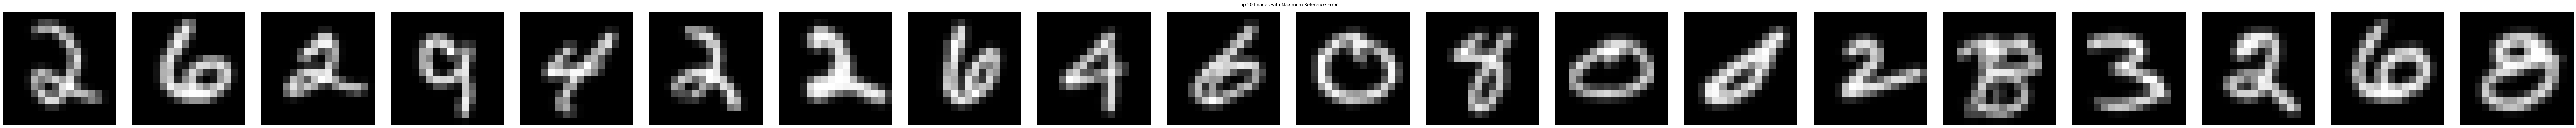

In [19]:
# Consider worst-performing images
fig, axes = plt.subplots(1, discard_highest_error, figsize=(5*discard_highest_error, 5))
fig.suptitle(f'Top {discard_highest_error} Images with Maximum Reference Error')
for i in range(discard_highest_error):
    axes[i].imshow(ref_discarded_data[i].squeeze().cpu(), cmap='gray')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# For phi_errors
fig, axes = plt.subplots(1, discard_highest_error, figsize=(5*discard_highest_error, 5))
fig.suptitle(f'Top {discard_highest_error} Images with Maximum Reference Error')
for i in range(discard_highest_error):
    axes[i].imshow(phi_discarded_data[i].squeeze().cpu(), cmap='gray')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [20]:
def find_first_index_below_threshold(errors, threshold):
    for index, error in enumerate(errors):
        if error < threshold:
            return index
    return len(errors)  # Return length if no value is below threshold

# Define your epsilon values
epsilon = [0.1, 0.05, 0.01]

# For each solver and each epsilon, find the first index
for eps in epsilon:
    ref_index = find_first_index_below_threshold(ref_restricted_rel_errors, eps)
    phi_index = find_first_index_below_threshold(phi_restricted_rel_errors, eps)
    
    print(f"For epsilon = {eps}:")
    print(f"  ref solver: {ref_index}")
    print(f"  phi solver: {phi_index}")

For epsilon = 0.1:
  ref solver: 18
  phi solver: 18
For epsilon = 0.05:
  ref solver: 29
  phi solver: 31
For epsilon = 0.01:
  ref solver: 50
  phi solver: 50


In [21]:
def plot_embedding(X, images, labels):
    _, ax = plt.subplots()
    X = MinMaxScaler().fit_transform(X)

    for digit in [1,2]:
        ax.scatter(
            X[labels == digit, 0], X[labels == digit, 1],
            marker=f"${digit}$",
            s=60,
            color=plt.cm.Dark2(digit),
            alpha=0,
            # alpha=0.425,
            zorder=2,
        )
    shown_images = np.array([[1.0, 1.0]])  # just something big
    for i in range(X.shape[0]):
        # plot every digit on the embedding
        # show an annotation box for a group of digits
        dist = np.sum((X[i] - shown_images) ** 2, 1)
        if np.min(dist) < 4e-3:
            # don't show points that are too close
            continue
        shown_images = np.concatenate([shown_images, [X[i]]], axis=0)
        imagebox = offsetbox.AnnotationBbox(
            offsetbox.OffsetImage(images[i][0], cmap=plt.cm.gray_r), X[i]
        )
        imagebox.set(zorder=1)
        ax.add_artist(imagebox)

    # ax.set_title(title)
    ax.axis("off")

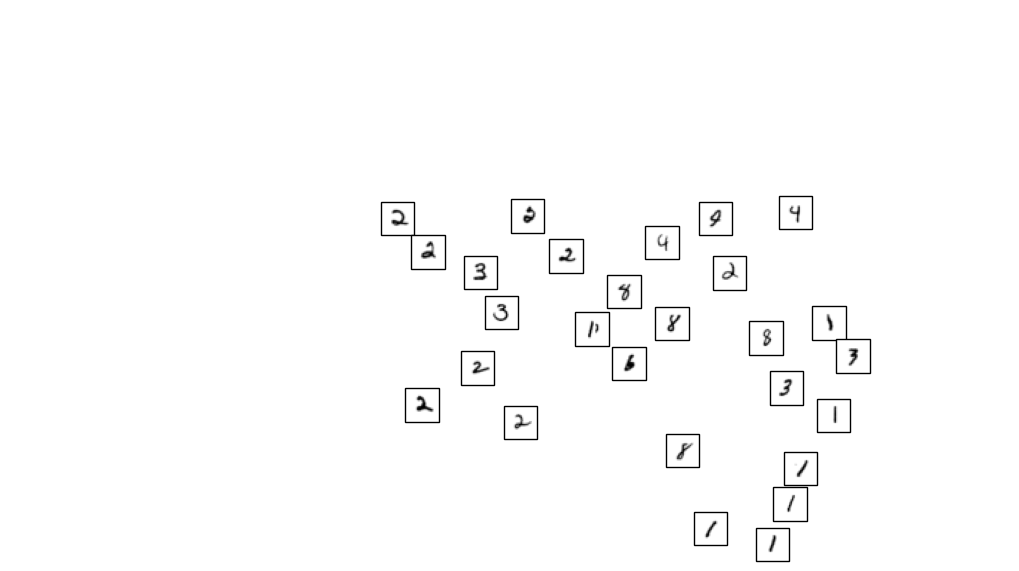

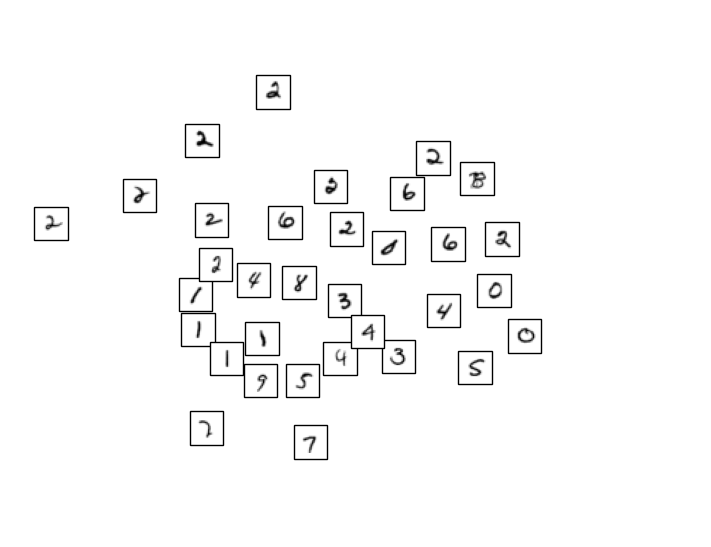

In [22]:
plot_embedding(ref_l2_pga_solver.U[:,:2], val_images, val_labels)
plot_embedding(phi_l2_pga_solver.U[:,:2], val_images, val_labels)